In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.style.use('seaborn-v0_8-darkgrid')

In [4]:
# loading clean data

data = pd.read_csv('../data/processed/cleaned_data.csv', index_col='Date', parse_dates=True)

df = data.copy()

print("Shape:", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())
print("Columns:", df.columns.tolist())
df.head()

Shape: (1075, 11)
Date range: 2023-01-12 to 2025-12-21
Columns: ['cbp_apprehended', 'cbp_custody', 'cbp_transferred', 'hhs_care', 'hhs_discharged', 'day_of_week', 'month', 'year', 'quarter', 'is_weekend', 'day_of_year']


,cbp_apprehended,cbp_custody,cbp_transferred,hhs_care,hhs_discharged,day_of_week,month,year,quarter,is_weekend,day_of_year
Date,,,,,,,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0,3,1,2023,1,0,12
2023-01-13,32.9,52.6,34.5,6621.6,415.1,4,1,2023,1,0,13
2023-01-14,32.8,52.2,35.0,6677.2,394.2,5,1,2023,1,1,14
2023-01-15,32.7,51.8,35.5,6732.8,373.3,6,1,2023,1,1,15
2023-01-16,32.6,51.4,36.0,6788.4,352.4,0,1,2023,1,0,16


In [5]:
# Lag features

# Lag features for hhs_care (our target variable)

lag_days = [1, 2, 3, 7, 14]

for lag in lag_days:
    df[f'hhs_care_lag_{lag}'] = df['hhs_care'].shift(lag)

print("Lag features created:")
print([col for col in df.columns if 'lag' in col])
df[['hhs_care'] + [f'hhs_care_lag_{l}' for l in lag_days]].head(20)

Lag features created:
['hhs_care_lag_1', 'hhs_care_lag_2', 'hhs_care_lag_3', 'hhs_care_lag_7', 'hhs_care_lag_14']


,hhs_care,hhs_care_lag_1,hhs_care_lag_2,hhs_care_lag_3,hhs_care_lag_7,hhs_care_lag_14
Date,,,,,,
2023-01-12,6566.0,NaN,NaN,NaN,NaN,NaN
2023-01-13,6621.6,6566.0,NaN,NaN,NaN,NaN
2023-01-14,6677.2,6621.6,6566.0,NaN,NaN,NaN
2023-01-15,6732.8,6677.2,6621.6,6566.0,NaN,NaN
2023-01-16,6788.4,6732.8,6677.2,6621.6,NaN,NaN
2023-01-17,6844.0,6788.4,6732.8,6677.2,NaN,NaN
2023-01-18,6899.6,6844.0,6788.4,6732.8,NaN,NaN
2023-01-19,6955.2,6899.6,6844.0,6788.4,6566.0,NaN
2023-01-20,7010.8,6955.2,6899.6,6844.0,6621.6,NaN


In [6]:
# Rolling Mean Features

# Rolling means for hhs_care
windows = [7, 14, 30]

for window in windows:
    df[f'hhs_care_roll_mean_{window}'] = df['hhs_care'].shift(1).rolling(window=window).mean()

print("Rolling mean features created:")
print([col for col in df.columns if 'roll_mean' in col])

Rolling mean features created:
['hhs_care_roll_mean_7', 'hhs_care_roll_mean_14', 'hhs_care_roll_mean_30']


In [7]:
# Rolling Standard Deviation Features

for window in windows:
    df[f'hhs_care_roll_std_{window}'] = df['hhs_care'].shift(1).rolling(window=window).std()

print("Rolling std features created:")
print([col for col in df.columns if 'roll_std' in col])

Rolling std features created:
['hhs_care_roll_std_7', 'hhs_care_roll_std_14', 'hhs_care_roll_std_30']


In [8]:
# Net Flow Feature

# Net pressure indicator — transfers in minus discharges out
df['net_flow'] = df['cbp_transferred'] - df['hhs_discharged']

# Rolling net flow
df['net_flow_roll_7']  = df['net_flow'].shift(1).rolling(window=7).mean()
df['net_flow_roll_14'] = df['net_flow'].shift(1).rolling(window=14).mean()

print("Net flow features created:")
print([col for col in df.columns if 'net_flow' in col])
df[['cbp_transferred', 'hhs_discharged', 'net_flow']].describe()

Net flow features created:
['net_flow', 'net_flow_roll_7', 'net_flow_roll_14']


,cbp_transferred,hhs_discharged,net_flow
count,1075.000000,1075.000000,1075.000000
mean,127.928837,182.692093,-54.763256
std,97.327004,131.309661,100.408021
min,0.000000,0.000000,-465.000000
25%,14.333333,19.833333,-112.000000
50%,157.000000,191.000000,-16.000000
75%,196.833333,286.000000,4.000000
max,440.000000,505.000000,206.000000


In [9]:
#  Intake Ratio Feature

# Ratio of transfers to discharges — system pressure ratio
df['intake_ratio'] = df['cbp_transferred'] / (df['hhs_discharged'] + 1)

# Rolling intake ratio
df['intake_ratio_roll_7'] = df['intake_ratio'].shift(1).rolling(window=7).mean()

print("Intake ratio features created:")
print([col for col in df.columns if 'intake' in col])

Intake ratio features created:
['intake_ratio', 'intake_ratio_roll_7']


In [10]:
# Lag Features for Other columns

# Lag features for supporting columns
support_cols = {
    'cbp_transferred' : [1, 7],
    'hhs_discharged'  : [1, 7],
    'cbp_apprehended' : [1, 7],
}

for col, lags in support_cols.items():
    for lag in lags:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

print("Support column lag features created:")
print([col for col in df.columns if 'transferred_lag' in col or 
       'discharged_lag' in col or 'apprehended_lag' in col])

Support column lag features created:
['cbp_transferred_lag_1', 'cbp_transferred_lag_7', 'hhs_discharged_lag_1', 'hhs_discharged_lag_7', 'cbp_apprehended_lag_1', 'cbp_apprehended_lag_7']


In [11]:
# Calendar Features Enhancement

# These already exist from preprocessing but we enhance them
df['is_month_start'] = (df.index.day <= 3).astype(int)
df['is_month_end']   = (df.index.day >= 28).astype(int)
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter',  2: 'Winter',
    3 : 'Spring', 4: 'Spring',  5: 'Spring',
    6 : 'Summer', 7: 'Summer',  8: 'Summer',
    9 : 'Fall',   10: 'Fall',   11: 'Fall'
})
df['season_encoded'] = df['season'].map(
    {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Fall': 3}
)
df.drop(columns=['season'], inplace=True)

print("Calendar features added:")
print(['is_month_start', 'is_month_end', 'season_encoded'])

Calendar features added:
['is_month_start', 'is_month_end', 'season_encoded']


In [12]:
# Days Since Surge Feature

# Rolling max to detect if we are near a recent peak
df['hhs_care_roll_max_30'] = df['hhs_care'].shift(1).rolling(window=30).max()
df['hhs_care_roll_min_30'] = df['hhs_care'].shift(1).rolling(window=30).min()

# Position within recent range — 0 means at recent low, 1 means at recent high
df['hhs_care_range_position'] = (
    (df['hhs_care'] - df['hhs_care_roll_min_30']) /
    (df['hhs_care_roll_max_30'] - df['hhs_care_roll_min_30'] + 1)
)

print("Range position feature created")
print(df['hhs_care_range_position'].describe())

Range position feature created
count    1045.000000
mean        0.534744
std         0.462950
min        -0.475000
25%         0.019920
50%         0.661972
75%         0.977591
max         1.390041
Name: hhs_care_range_position, dtype: float64


In [13]:
# Droping NaN Rows Created by Lags

print(f"Shape before dropping NaN rows : {df.shape}")
print(f"NaN values before              : {df.isnull().sum().sum()}")

df.dropna(inplace=True)

print(f"\nShape after dropping NaN rows  : {df.shape}")
print(f"NaN values after               : {df.isnull().sum().sum()}")
print(f"\nRows removed due to lag NaNs   : {1075 - len(df)}")

Shape before dropping NaN rows : (1075, 39)
NaN values before              : 271

Shape after dropping NaN rows  : (1045, 39)
NaN values after               : 0

Rows removed due to lag NaNs   : 30


In [15]:
feature_cols = [col for col in df.columns if col != 'hhs_care']

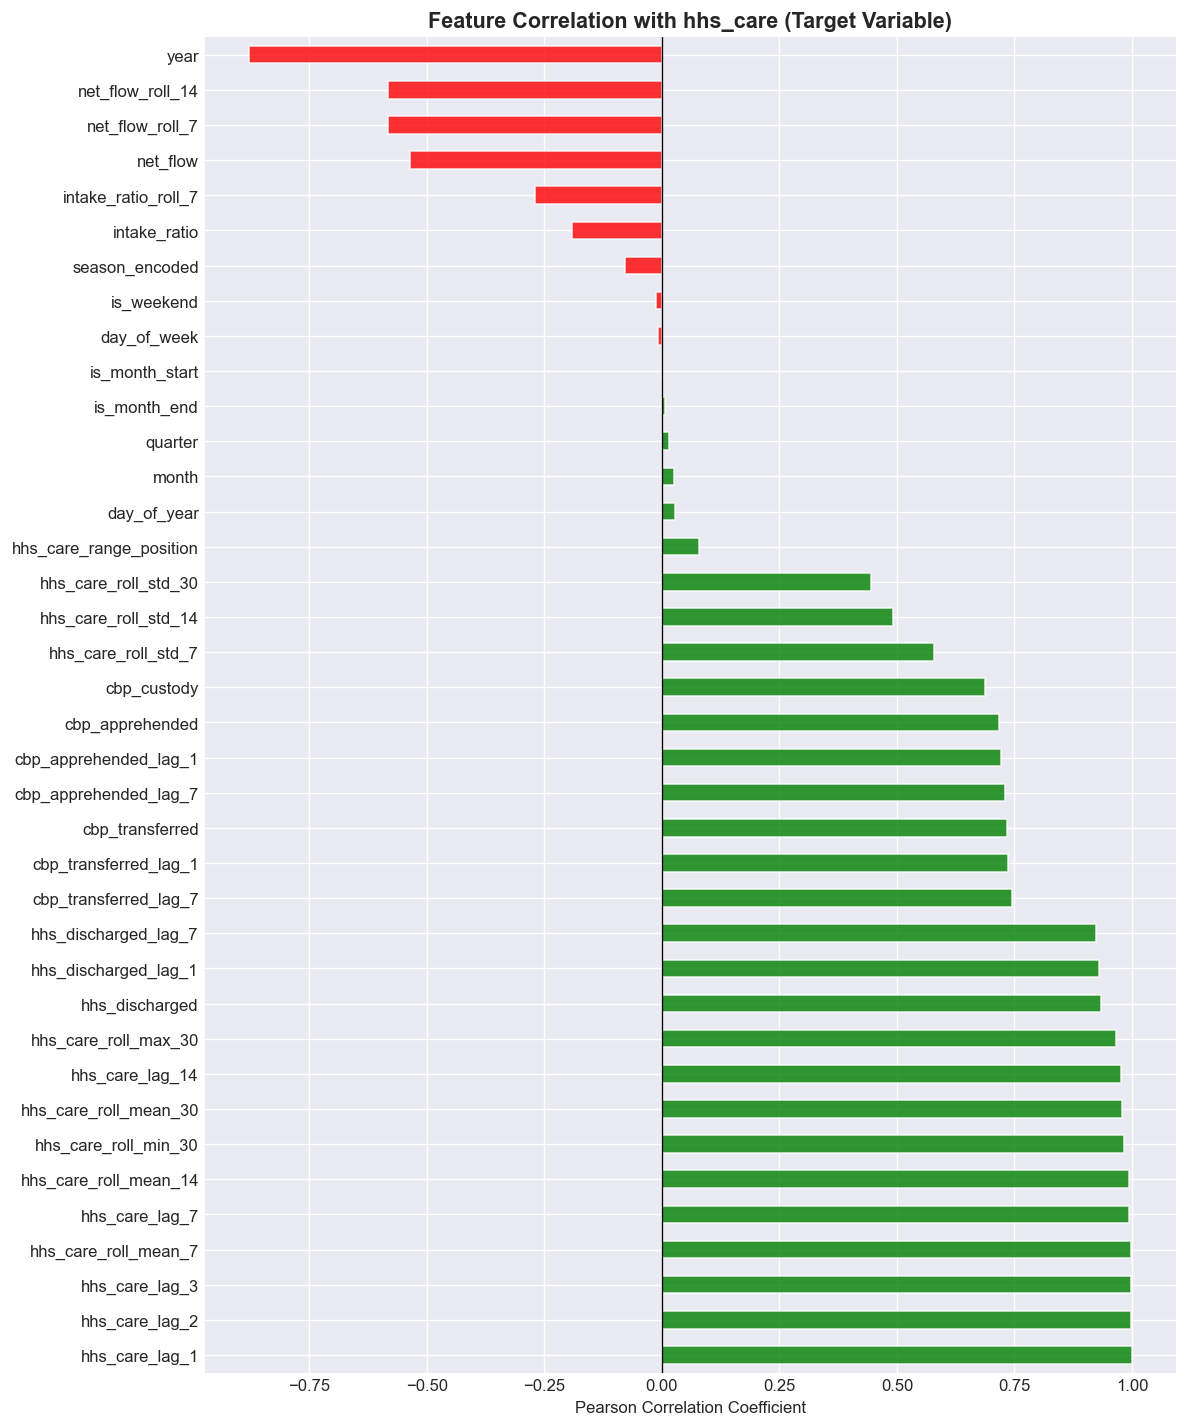


Top 10 most correlated features:
hhs_care_lag_1           0.999623
hhs_care_lag_2           0.998800
hhs_care_lag_3           0.997781
hhs_care_roll_mean_7     0.997457
hhs_care_lag_7           0.993047
hhs_care_roll_mean_14    0.992810
hhs_care_roll_min_30     0.982758
hhs_care_roll_mean_30    0.978072
hhs_care_lag_14          0.977226
hhs_care_roll_max_30     0.965606
dtype: float64

Bottom 5 least correlated features:
intake_ratio_roll_7   -0.269881
net_flow              -0.536132
net_flow_roll_7       -0.582821
net_flow_roll_14      -0.583099
year                  -0.878633
dtype: float64


In [16]:
# Feature Correlation with Target

correlations = df[feature_cols].corrwith(df['hhs_care']).sort_values(ascending=False)

plt.figure(figsize=(10, 12))
colors = ['green' if x > 0 else 'red' for x in correlations.values]
correlations.plot(kind='barh', color=colors, edgecolor='white', alpha=0.8)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Correlation with hhs_care (Target Variable)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../reports/figures/feature_correlation.png', bbox_inches='tight')
plt.show()

print("\nTop 10 most correlated features:")
print(correlations.head(10))
print("\nBottom 5 least correlated features:")
print(correlations.tail(5))

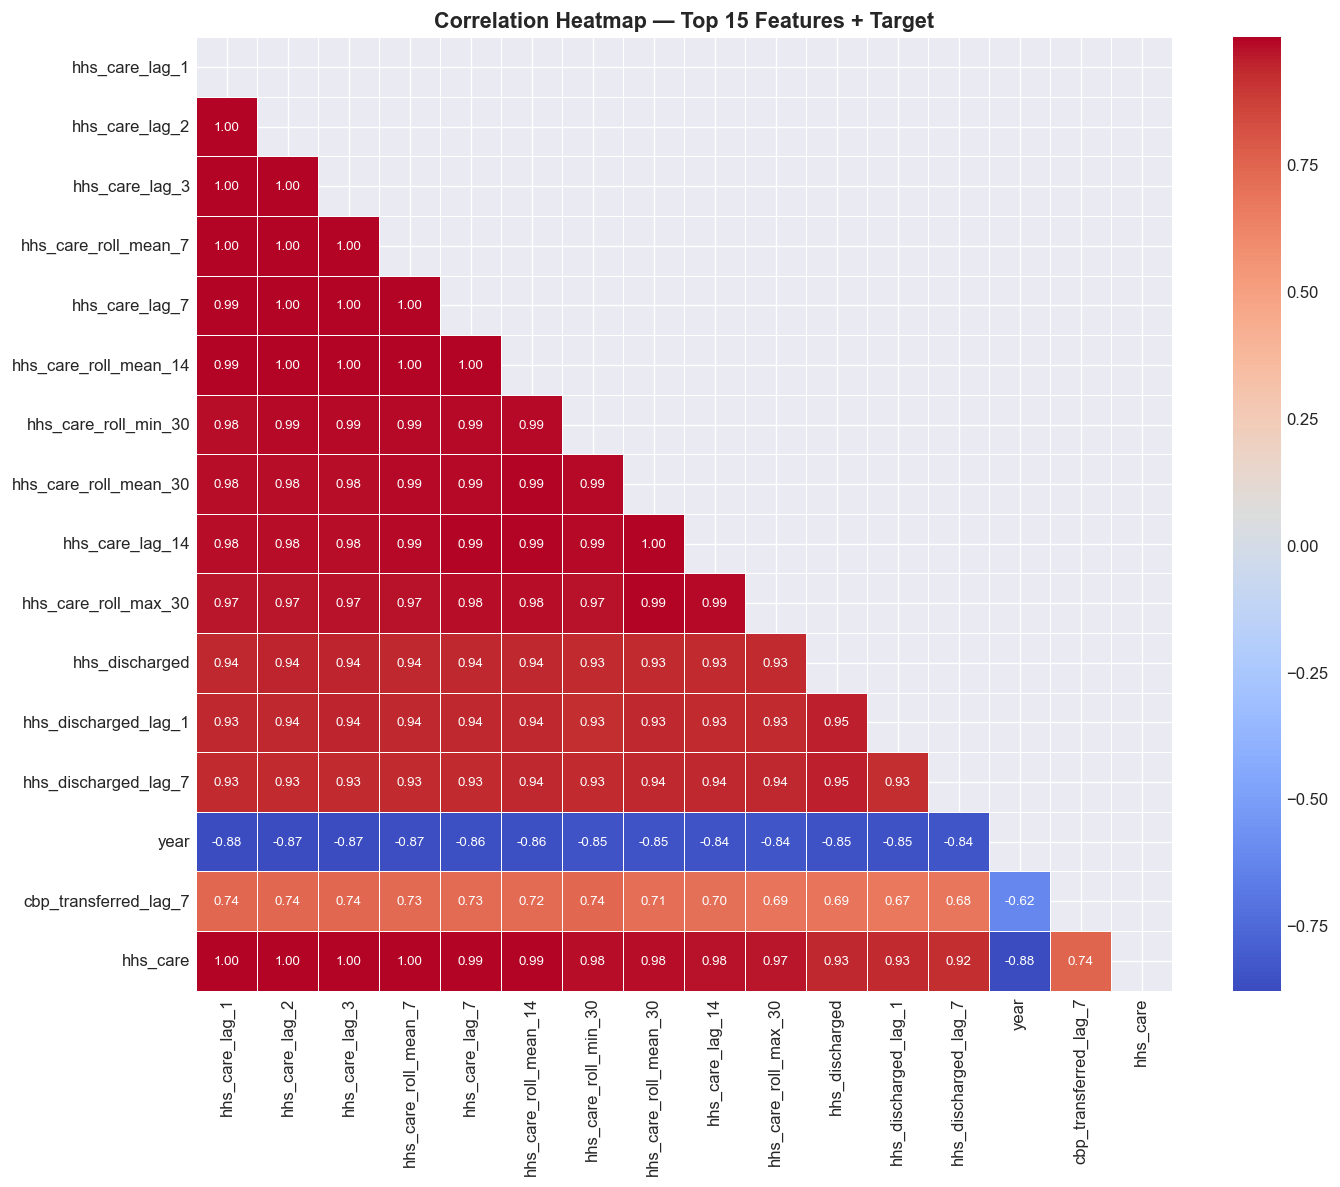

In [17]:
# Feature Correlation Heatmap

top_features = correlations.abs().sort_values(ascending=False).head(15).index.tolist()
top_features = top_features + ['hhs_care']

plt.figure(figsize=(12, 10))
corr_matrix = df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap — Top 15 Features + Target',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_heatmap.png', bbox_inches='tight')
plt.show()

In [18]:
df.to_csv('../data/processed/featured_data.csv')

print("Featured data saved to: data/processed/featured_data.csv")
print(f"Final shape: {df.shape}")
print(f"Total features: {len(feature_cols)}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.head()

Featured data saved to: data/processed/featured_data.csv
Final shape: (1045, 39)
Total features: 38
Date range: 2023-02-11 to 2025-12-21


,cbp_apprehended,cbp_custody,cbp_transferred,hhs_care,hhs_discharged,day_of_week,month,year,quarter,is_weekend,...,hhs_discharged_lag_1,hhs_discharged_lag_7,cbp_apprehended_lag_1,cbp_apprehended_lag_7,is_month_start,is_month_end,season_encoded,hhs_care_roll_max_30,hhs_care_roll_min_30,hhs_care_range_position
Date,,,,,,,,,,,,,,,,,,,,,
2023-02-11,102.666667,213.333333,169.0,7592.0,329.0,5,2,2023,1,1,...,341.0,327.333333,113.333333,15.666667,0,0,0,7915.0,6566.0,0.760000
2023-02-12,92.000000,203.000000,173.0,7434.0,317.0,6,2,2023,1,1,...,329.0,342.000000,102.666667,16.000000,0,0,0,7915.0,6621.6,0.627627
2023-02-13,186.000000,259.000000,172.0,7483.0,244.0,0,2,2023,1,0,...,317.0,196.000000,92.000000,11.000000,0,0,0,7915.0,6677.2,0.650468
2023-02-14,154.000000,225.000000,220.0,7794.0,223.0,1,2,2023,1,0,...,244.0,200.000000,186.000000,16.000000,0,0,0,7915.0,6732.8,0.896890
2023-02-15,91.000000,199.000000,172.0,7869.0,290.0,2,2,2023,1,0,...,223.0,317.000000,154.000000,93.000000,0,0,0,7915.0,6788.4,0.958319
